In [2]:
!python --version

Python 3.8.20


<a id="home"></a>

# Contents
- [1. Load data](#download_data)
- [2. Create UpliftPipeline object](#import_library)
- [3. Load sample in the pipeline](#load_sample)
- [4. Main pipeline method: run()](#run)
- [5. Inference model on some sample](#inference)
- [6. Evaluate model on some sample](#evaluate)

<a id="download_data"></a>

# 1. Load data

[Contents](#home)

In [3]:
import pandas as pd
from sklift import datasets

data, target, treatment = datasets.fetch_megafon(
    download_if_missing=True,
    return_X_y_t=True
)

df = pd.concat([data, target, treatment], axis=1)
df["id"] = list(range(df.shape[0]))

print(df.shape)
df.head(2)

/home/melvik/AUF/auf/.venv/lib/python3.8/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


(600000, 53)


,X_1,X_2,X_3,X_4,X_5,X_6,X_7,X_8,X_9,X_10,...,X_44,X_45,X_46,X_47,X_48,X_49,X_50,conversion,treatment_group,id
0,39.396577,-0.186548,19.524505,21.250208,55.291264,182.966712,-5.385606,144.573379,-12.534344,-58.279429,...,-2.092461,-93.973258,-0.155597,-312.130733,44.798182,-125.682413,16.231365,0,control,0
1,38.987694,0.819522,-42.064512,-48.270949,-33.171257,179.459341,-87.151810,-162.693257,20.651652,181.635081,...,1.142391,80.037124,-1.216185,-111.473936,-127.737977,-117.501171,10.732234,0,control,1


<a id="import_library"></a>

# 2. Create UpliftPipeline object

[Contents](#home)

In [4]:
import auf
print(auf.__version__)

2.0.0


In [5]:
from auf.pipeline import UpliftPipeline

pipeline = UpliftPipeline(
    print_doc=False,
    task_name_mlflow=None,
)

<a id="load_sample"></a>

# 3. Load sample in the pipeline

[Contents](#home)

In [6]:
# Map unified base columns names to custom names from dataframe
base_cols_mapper = {
    "id": "id",
    "treatment": "treatment_group",
    "target": "conversion",
    "segm": None  # "segm"
}

# Map treatment groups from base_cols_mapper["treatment"] to numbers
treatment_groups_mapper = {
    "control": 0,
    "treatment": 1
}

pipeline.load_sample(
    df,
    base_cols_mapper,
    treatment_groups_mapper
)

19:44:45 INFO - Difference in target rates for 'treatment' and 'control' groups:
    pvalue = 0.000
    treatment target rate : 0.229
    control target rate   : 0.179


,treatment group,treatment target rate,control target rate,pvalue,equals
0,treatment,0.229,0.179,0.0,False


19:44:49 INFO - Preprocess features
19:44:50 INFO - Sample was succesfully loaded!


target_mean  target_sum  target_count
segm  treatment_group                                       
test  control             0.179402       10751         59927
      treatment           0.228921       13752         60073
train control             0.179398       32252        179779
      treatment           0.228919       41256        180221
val   control             0.179405       10751         59926
      treatment           0.228918       13752         60074

<a id="run"></a>

# 4. Main pipeline method: run()

[Contents](#home)

19:45:19 INFO - Start with cleaning feature list: remove leaks, unimportant features and so on.
19:51:26 INFO - Number of features after cleaning: 50
19:51:46 INFO - Number of features removed for each reason:
19:51:46 INFO -         0 : all values missed
19:51:46 INFO -         0 : only 1 unique value
19:51:46 INFO -         0 : treatment leaks
19:51:46 INFO -        20 : preselection
19:51:46 INFO -         7 : too correlated
19:51:46 INFO - Rank filtered feature list by different kinds of importance.
Ranking features: 100%|███████████████████████████████████████████████████████████████████████████████████████████████|
19:53:27 INFO - Train models using different number of top features from every sort method.
Training models: 0%|                                                                                                  |19:53:27 INFO - SoloModel training started
Training models. SoloModel training: : 14%|██████████▋                                                               

segm  uplift@10  \
model_name ranker_method n_features uplift_type                     
SoloModel  filter        10         abs          train      0.296   
                                    abs            val      0.305   
                                    abs           test      0.288   

                                                 uplift_rel@10  uplift@15  \
model_name ranker_method n_features uplift_type                             
SoloModel  filter        10         abs                  1.807      0.245   
                                    abs                  1.912      0.247   
                                    abs                  1.654      0.237   

                                                 uplift_rel@15  uplift@20  \
model_name ranker_method n_features uplift_type                             
SoloModel  filter        10         abs                  1.501      0.215   
                                    abs                  1.524      0.221   
                                    abs                  1.377      0.209   

                                                 uplift_rel@20  qini_auc  
model_name ranker_method n_features uplift_type                           
SoloModel  filter        10         abs                  1.314     0.181  
                                    abs                  1.356     0.181  
                                    abs                  1.223     0.174

,n_treatment,n_control,response_rate_treatment,response_rate_control,uplift,"rel_uplift, %",min_score,"control_target_ratio, %","treatment_target_ratio, %"
percentile,,,,,,,,,
0-10,5927,6073,0.461448,0.173884,0.287563,165.376075,0.024770,9.822342,19.888016
10-20,6059,5941,0.299554,0.167649,0.131906,78.679978,0.019929,9.264254,13.198080
20-30,6013,5987,0.270248,0.162853,0.107395,65.946006,0.017128,9.068924,11.816463
30-40,5948,6052,0.249496,0.168705,0.080791,47.889084,0.015103,9.496791,10.791158
40-50,5965,6035,0.239061,0.171168,0.067893,39.664500,0.013443,9.608409,10.369401
50-60,5990,6010,0.231553,0.183028,0.048524,26.511914,0.011878,10.231606,10.085806
60-70,6064,5936,0.224109,0.190869,0.033240,17.415180,0.010210,10.538555,9.882199
70-80,6088,5912,0.194809,0.204668,-0.009859,-4.817063,0.007672,11.254767,8.624200
80-90,5963,6037,0.082006,0.180222,-0.098216,-54.497388,0.000208,10.119989,3.555846


,top,final_response_rate,top_target_ratio_treatment,top_target_ratio_control,top_response_rate_treatment,top_response_rate_control,bottom_response_rate_treatment,bottom_response_rate_control
0,5%,0.199189,0.122673,0.048647,0.568205,0.172550,0.211281,0.179767
1,10%,0.208166,0.198880,0.098223,0.461448,0.173884,0.203468,0.180024
2,15%,0.214909,0.265561,0.144824,0.408501,0.171854,0.197524,0.180746
3,20%,0.221169,0.330861,0.190866,0.379610,0.170801,0.191361,0.181558
4,25%,0.226296,0.391070,0.237838,0.358199,0.170626,0.185845,0.182328
5,30%,0.231883,0.449026,0.281555,0.343075,0.168157,0.180087,0.184229
6,35%,0.236057,0.503563,0.329179,0.330155,0.168323,0.174613,0.185389
7,40%,0.240042,0.556937,0.376523,0.319831,0.168295,0.168660,0.186848


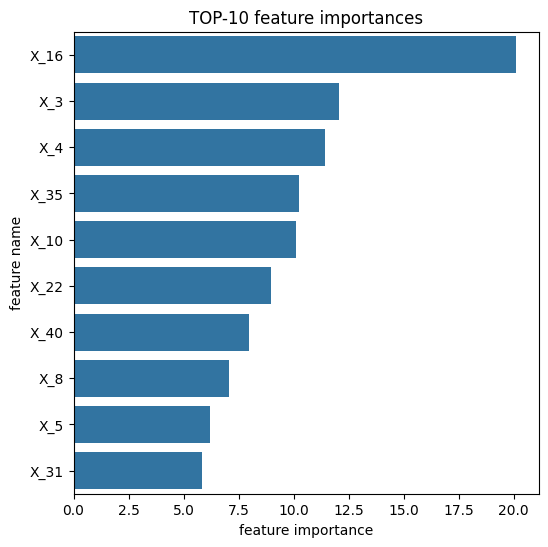

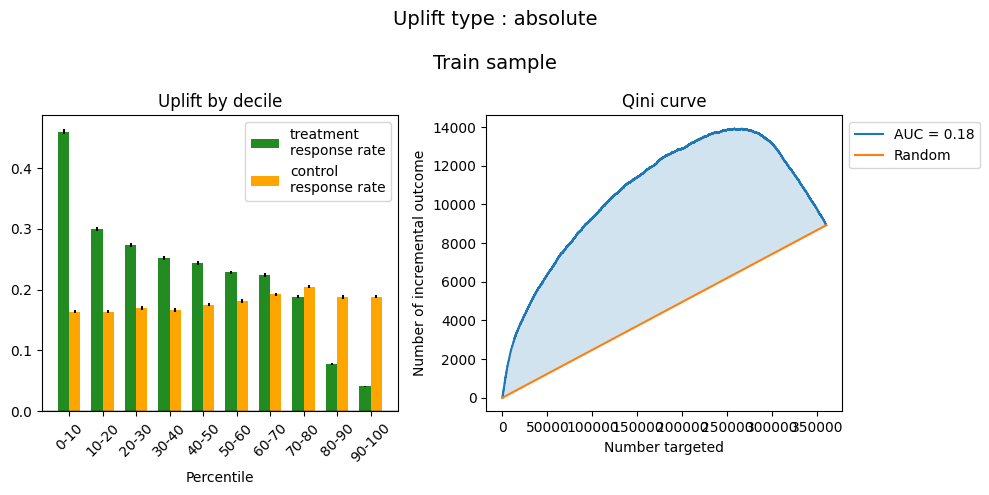

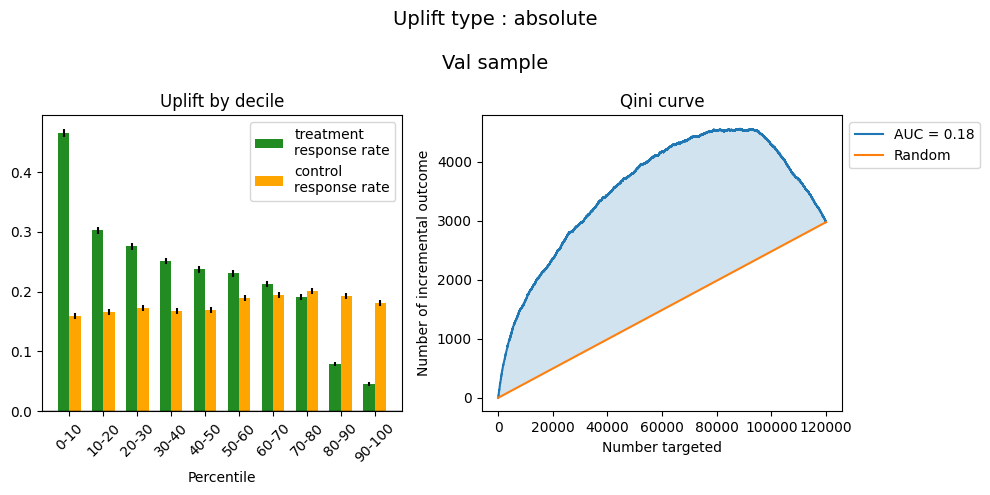

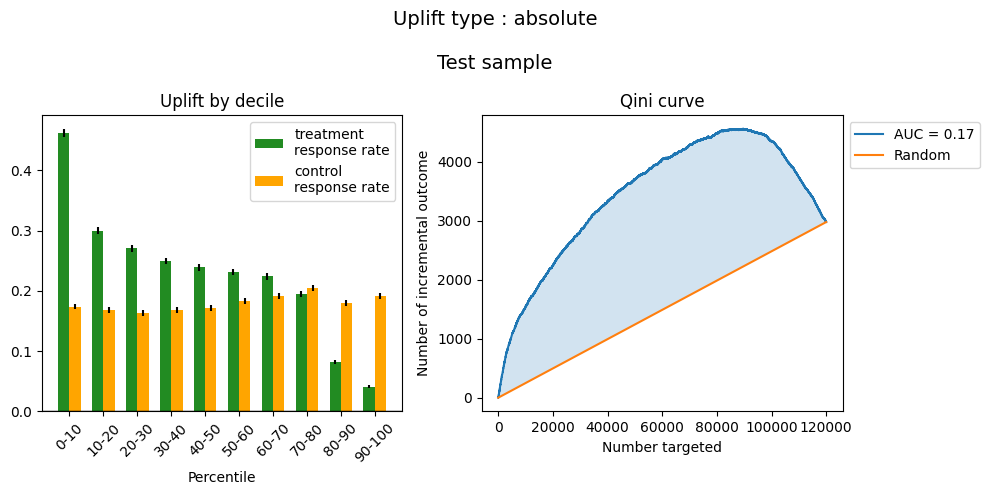

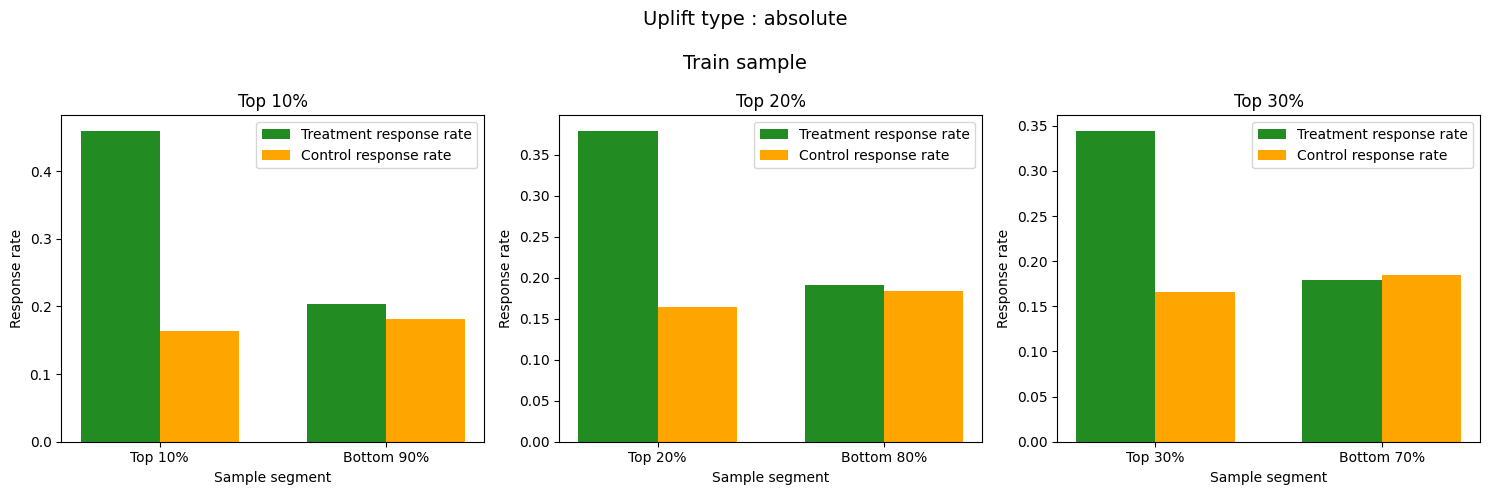

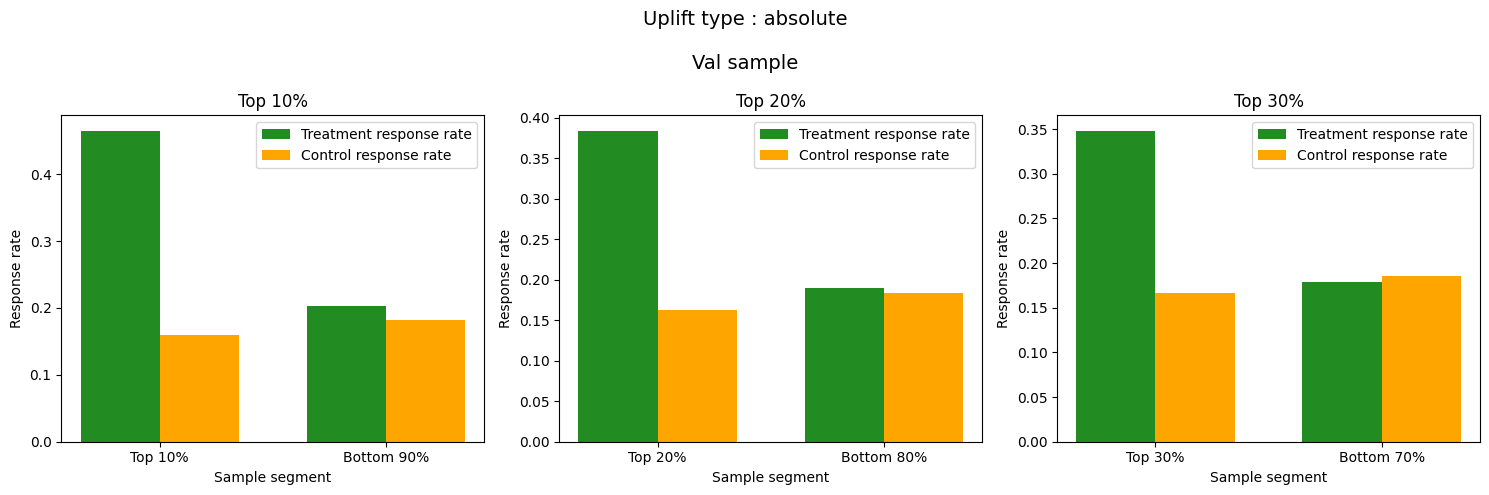

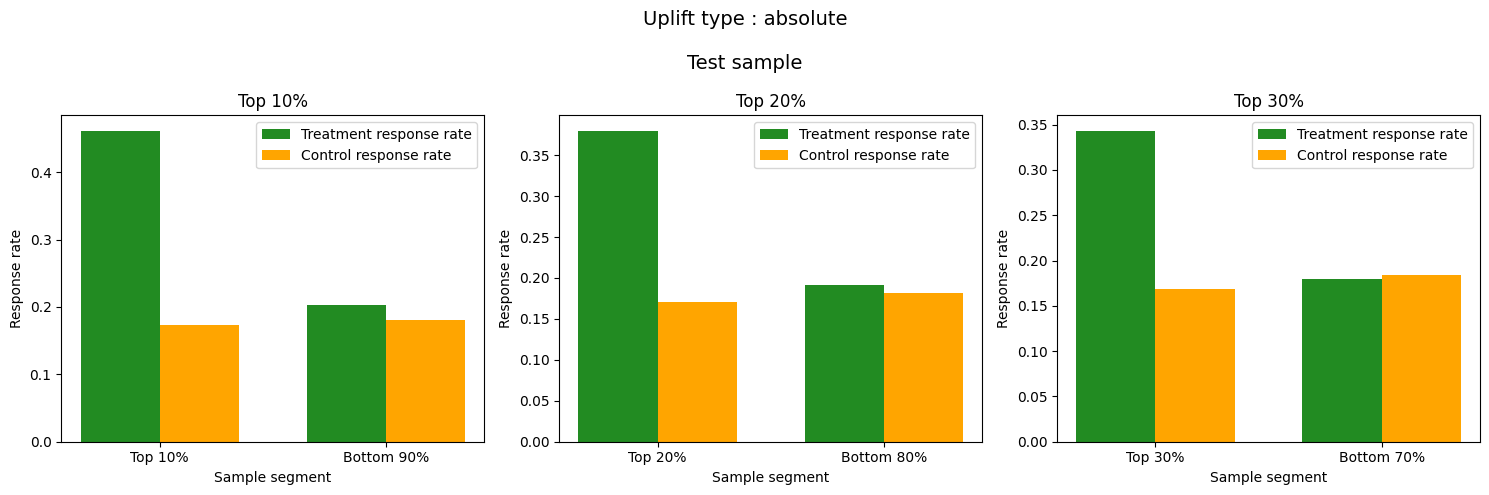

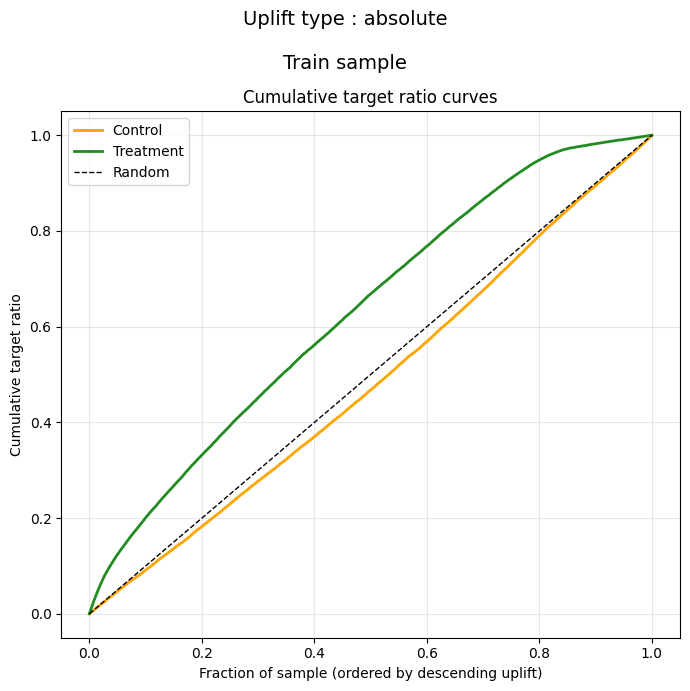

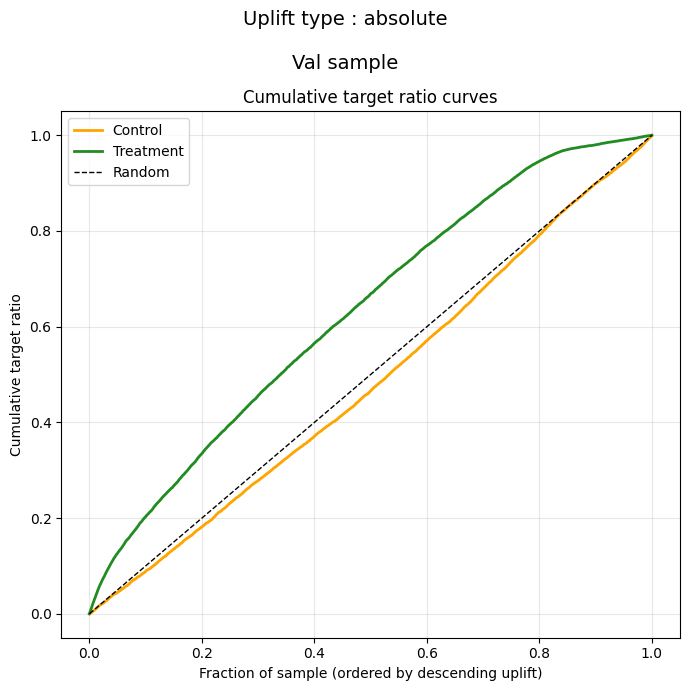

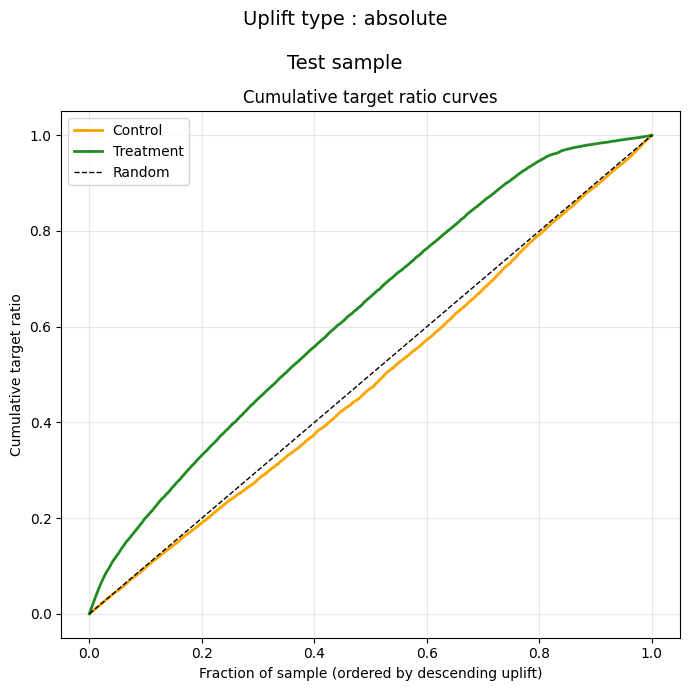

segm  uplift@10  \
model_name ranker_method n_features uplift_type                     
baseline   propensity    50         propensity   train     -0.122   
                                    propensity     val     -0.125   
                                    propensity    test     -0.106   

                                                 uplift_rel@10  uplift@15  \
model_name ranker_method n_features uplift_type                             
baseline   propensity    50         propensity          -0.207     -0.077   
                                    propensity          -0.213     -0.081   
                                    propensity          -0.184     -0.075   

                                                 uplift_rel@15  uplift@20  \
model_name ranker_method n_features uplift_type                             
baseline   propensity    50         propensity          -0.157     -0.052   
                                    propensity          -0.165     -0.048   
                                    propensity          -0.154     -0.049   

                                                 uplift_rel@20  qini_auc  \
model_name ranker_method n_features uplift_type                            
baseline   propensity    50         propensity          -0.123    -0.072   
                                    propensity          -0.115    -0.063   
                                    propensity          -0.117    -0.061   

                                                 qini_clipped@20  
model_name ranker_method n_features uplift_type                   
baseline   propensity    50         propensity              -1.0  
                                    propensity              -1.0  
                                    propensity              -1.0

,method,coefficient
0,pearson,-0.032647
1,spearman,-0.075291
2,kendall,-0.050292


20:10:52 INFO - Propensity vs. uplift comparison completed. ROC AUC of uplift model on control group: 0.4821
20:10:52 INFO - Correlation coefficients: pearson=-0.033, spearman=-0.075, kendall=-0.050


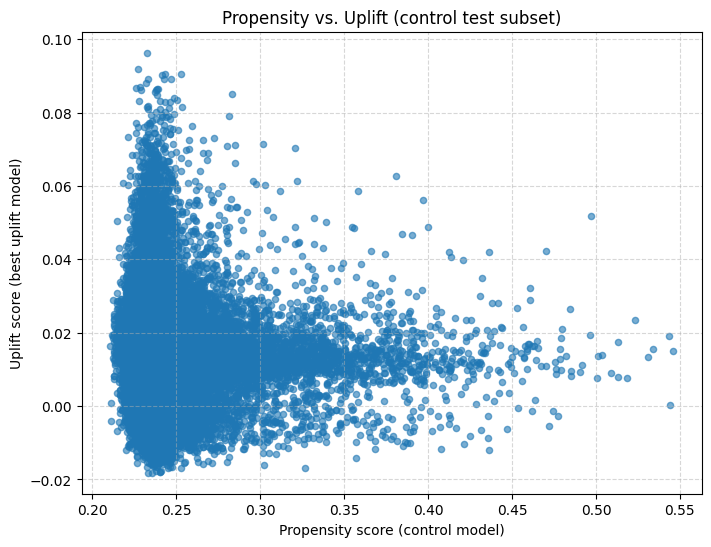

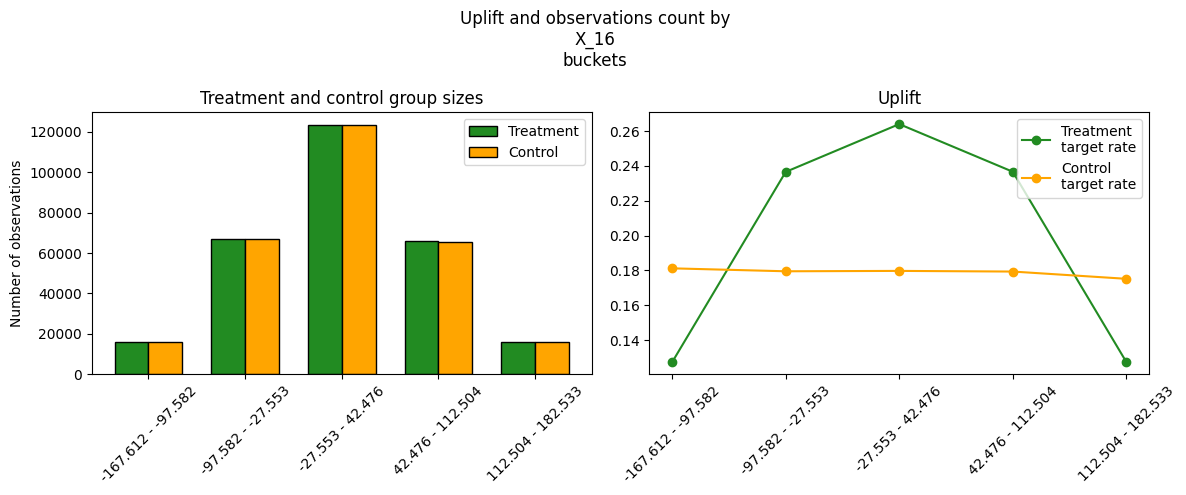

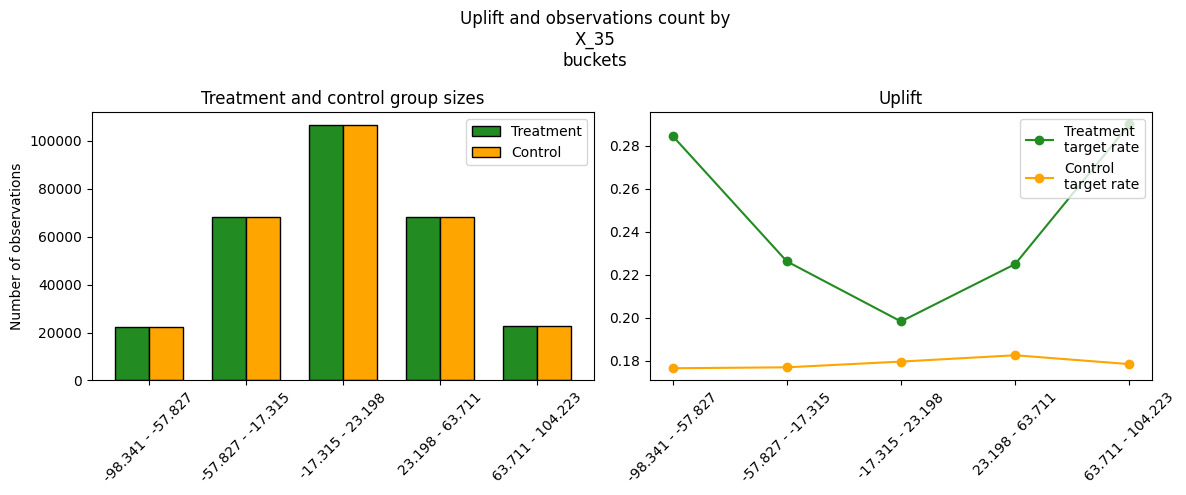

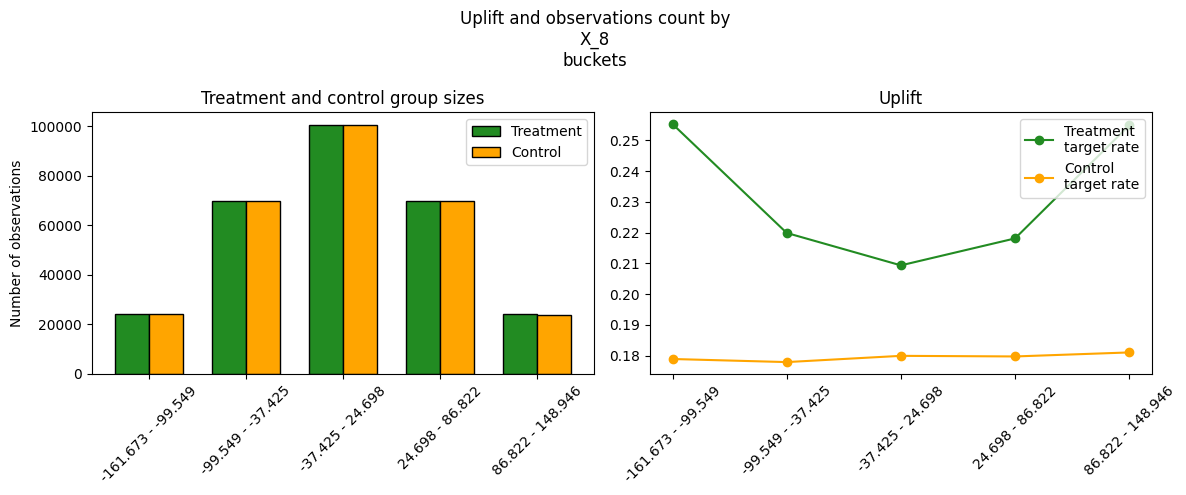

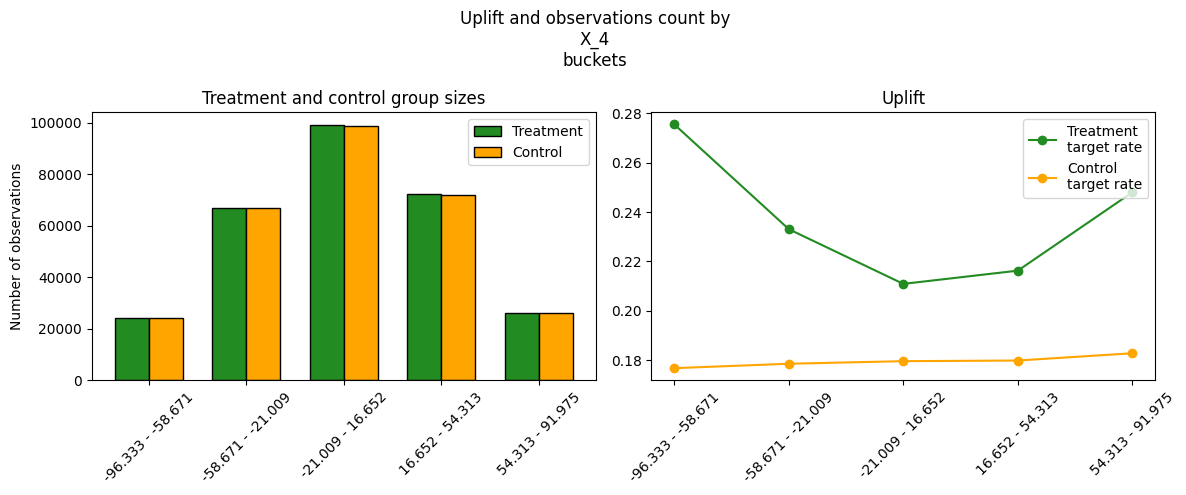

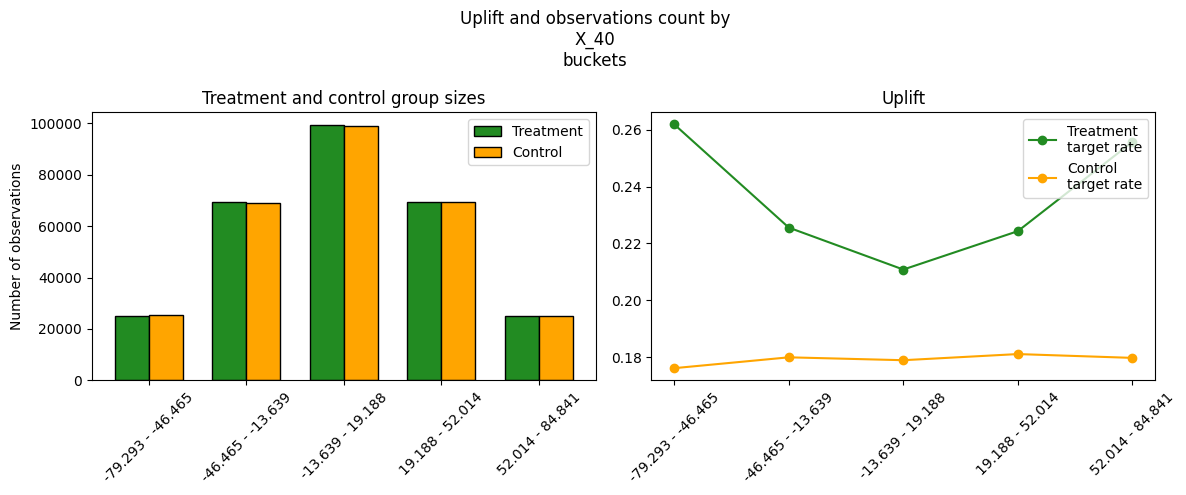

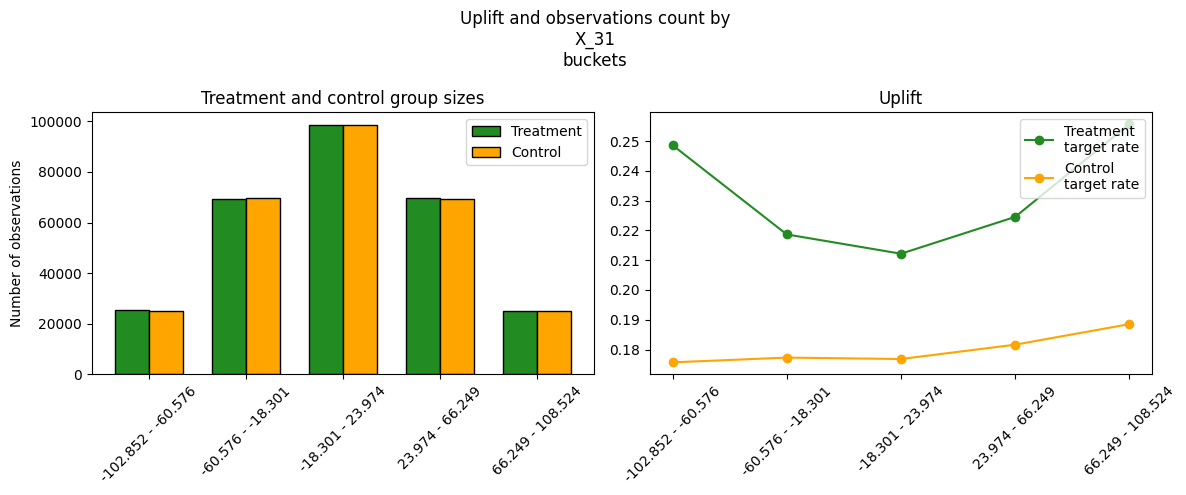

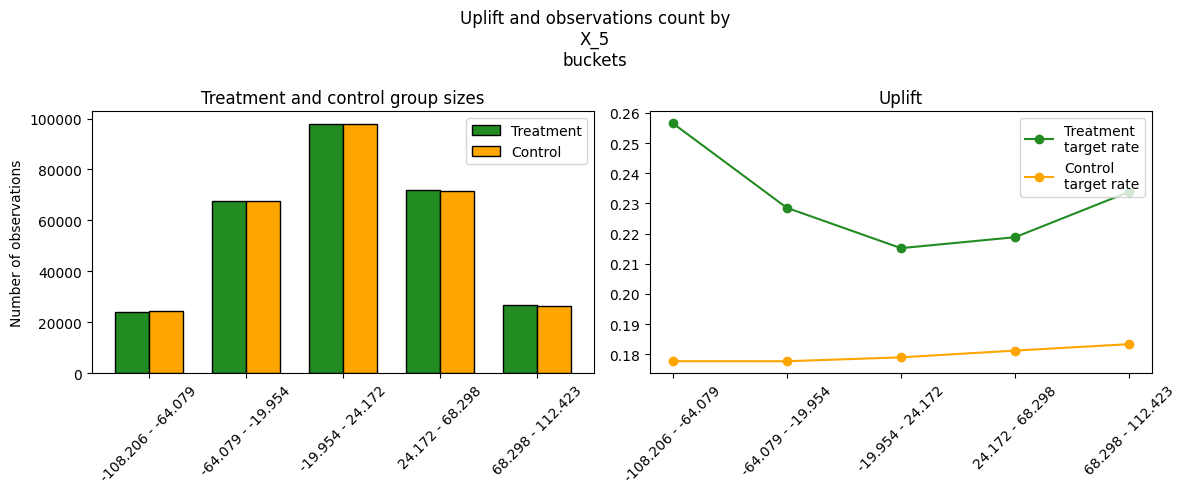

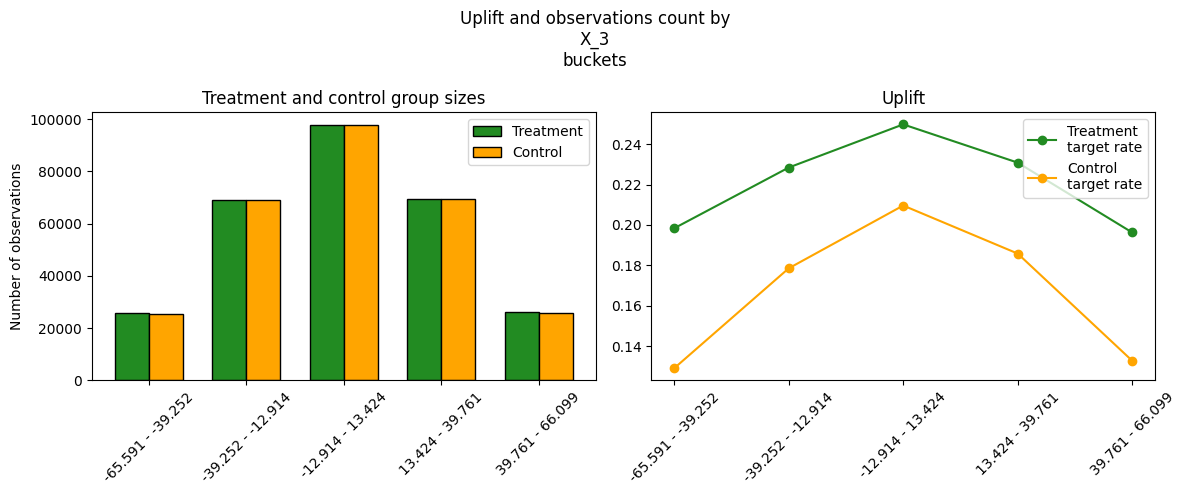

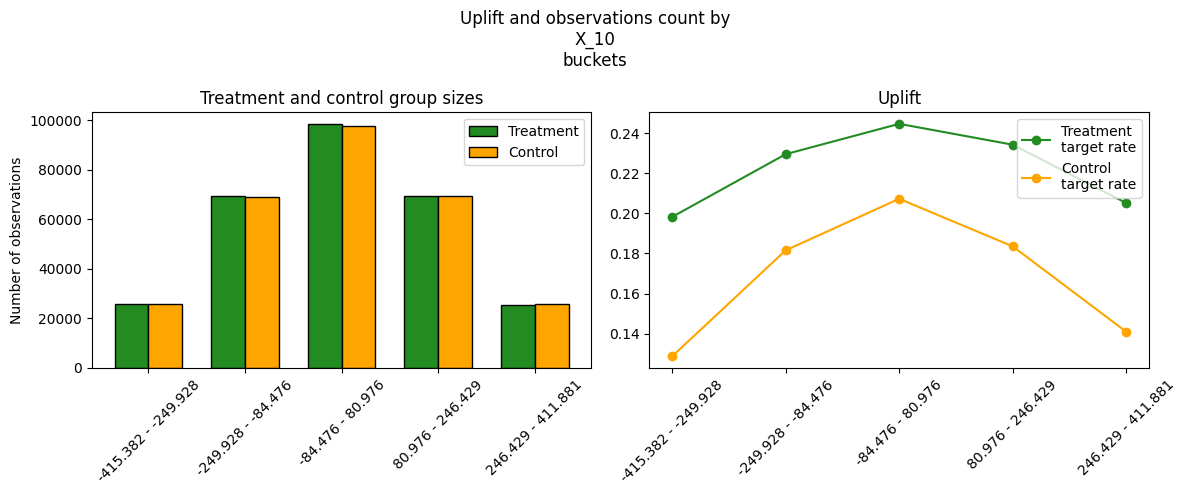

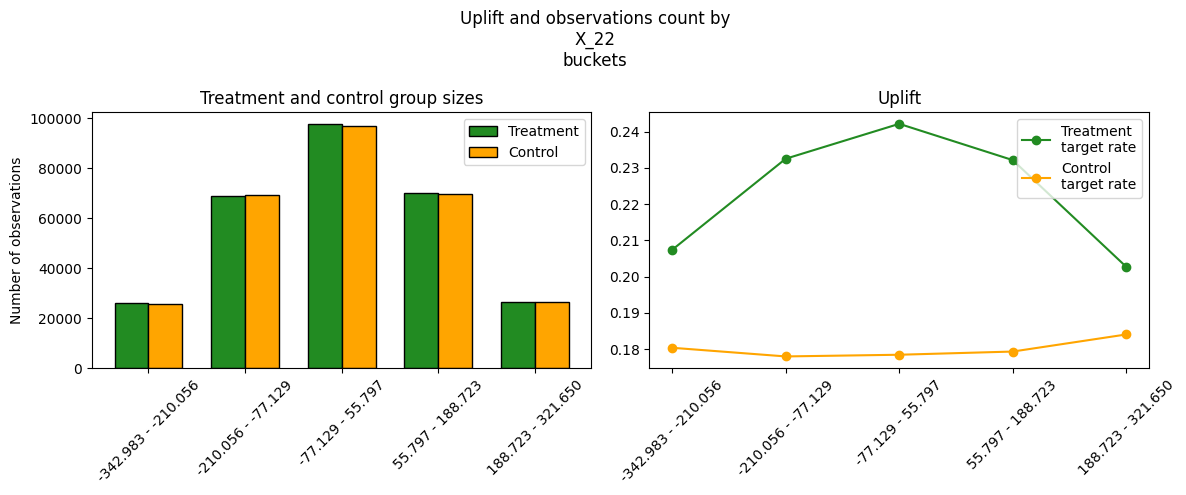

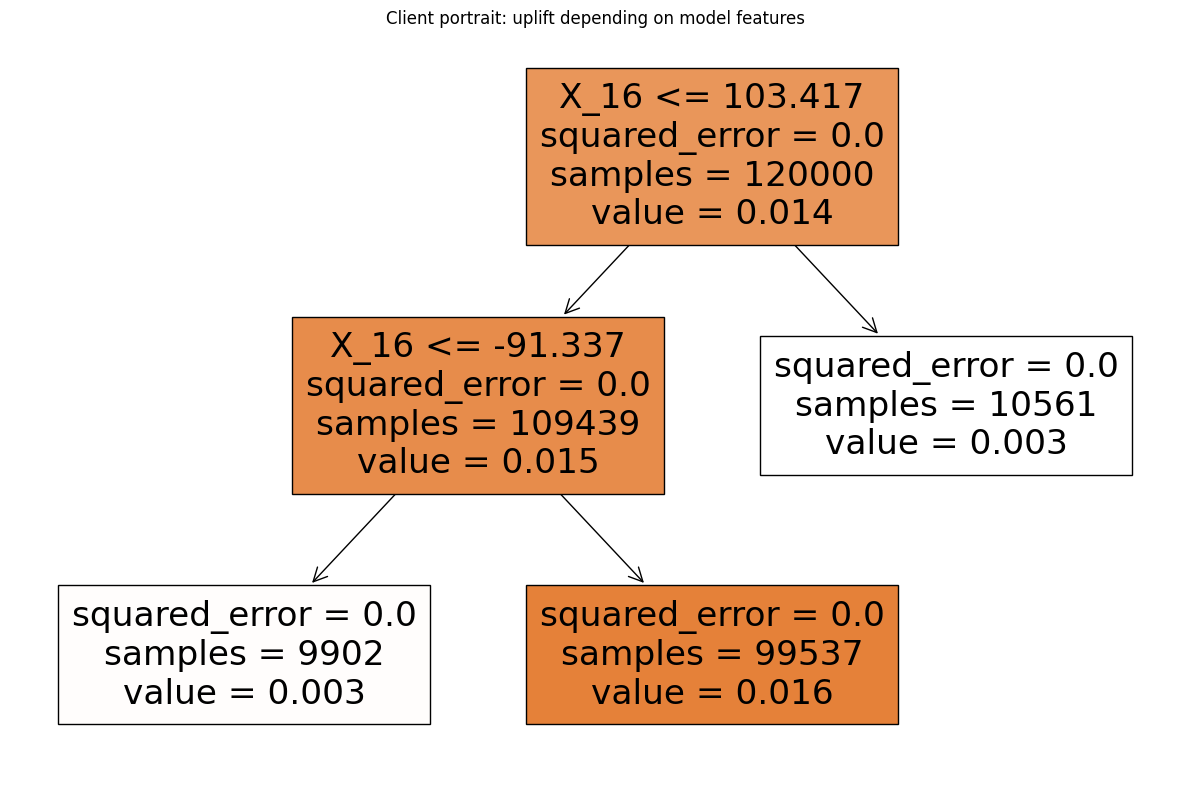

<Figure size 640x480 with 0 Axes>

In [7]:
preprocessor, model, calibrator = pipeline.run(
    max_val_roc_auc_treatment = 0.6,
    early_stopping = 10,
    max_abs_feature_correlation = 0.9,
    n_features_candidates = 30,
    classes_for_train = [
        "SoloModel",
        "TwoModels",
        "AufXLearner",
        # "AufTreeClassifier",
        # "AufRandomForestClassifier"
    ],
    feature_nums = {
        "SoloModel": [10, 20],
        "TwoModels": [10, 20],
        "AufXLearner": [5, 10],
        # "AufTreeClassifier": [5],
        # "AufRandomForestClassifier": [5],
    },
    timeout_estimator = {
        "SoloModel": 10,
        "TwoModels": 10,
        "AufXLearner": 10,
        # "AufTreeClassifier": 10,
        # "AufRandomForestClassifier": 10,
    },
    opt_metric = 'qini_auc',
    training_mode="medium",
    n_uplift_bins=10,
)

<a id="inference"></a>

# 5. Inference model on some sample

[Contents](#home)

In [8]:
test_df = df[pipeline._df["segm"] == "test"]
test_df.shape

(120000, 54)

In [9]:
# from auf.pipeline.inference import UpliftInference
# mlflow_inference_pipeline = UpliftInference(run_id=pipeline._run_id)
# mlflow_scores = mlflow_inference_pipeline.predict(test_df)
# mlflow_scores.head(2)

In [10]:
from auf.pipeline.inference import UpliftInference
local_inference_pipeline = UpliftInference(preprocessor, model, calibrator)
local_scores = local_inference_pipeline.predict(test_df)
local_scores.head(2)

,X_1,X_2,X_3,X_4,X_5,X_6,X_7,X_8,X_9,X_10,...,X_48,X_49,X_50,conversion,treatment_group,id,segm,trmnt_preds,ctrl_preds,score_raw
5,-0.639530,0.083205,11.722866,-22.561569,-29.253712,114.960502,-11.015233,-111.759927,35.970304,-169.279977,...,25.105122,65.048061,9.091517,0,control,5,test,0.276020,0.264801,0.017988
14,-2.189912,0.413319,-25.750203,-27.523793,-18.202603,380.009566,25.526265,-130.418800,19.888444,178.307614,...,-66.729673,-371.510643,-18.672816,0,treatment,14,test,0.273142,0.255662,0.097501


<a id="evaluate"></a>

# 6. Evaluate model on some sample 

[Contents](#home)

In [11]:
df2 = df[pipeline._df["segm"] == "test"].copy()
print(df2.shape)
df2.head(2)

(120000, 54)


,X_1,X_2,X_3,X_4,X_5,X_6,X_7,X_8,X_9,X_10,...,X_45,X_46,X_47,X_48,X_49,X_50,conversion,treatment_group,id,segm
5,-0.639530,0.083205,11.722866,-22.561569,-29.253712,114.960502,-11.015233,-111.759927,35.970304,-169.279977,...,11.011644,0.183690,262.560479,25.105122,65.048061,9.091517,0,control,5,test
14,-2.189912,0.413319,-25.750203,-27.523793,-18.202603,380.009566,25.526265,-130.418800,19.888444,178.307614,...,-30.976963,-0.690103,32.879065,-66.729673,-371.510643,-18.672816,0,treatment,14,test


,target_mean,target_sum,target_count
treatment,,,
0,0.179402,10751,59927
1,0.228921,13752,60073


,5,10,15,20,25
qini_auc,0.174266,0.174266,0.174266,0.174266,0.174266
uplift@k,0.395654,0.287563,0.236647,0.208809,0.187573
uplift_rel@k,2.29298,1.653761,1.37702,1.222529,1.099324
treatment_ones_ratios@k,0.122673,0.19888,0.265561,0.330861,0.39107
control_ones_ratios@k,0.951353,0.901777,0.855176,0.809134,0.762162


,n_treatment,n_control,response_rate_treatment,response_rate_control,uplift,"rel_uplift, %"
percentile,,,,,,
0-10,5927,6073,0.461448,0.173884,0.287563,165.376075
10-20,6059,5941,0.299554,0.167649,0.131906,78.679978
20-30,6013,5987,0.270248,0.162853,0.107395,65.946006
30-40,5948,6052,0.249496,0.168705,0.080791,47.889084
40-50,5965,6035,0.239061,0.171168,0.067893,39.664500
50-60,5990,6010,0.231553,0.183028,0.048524,26.511914
60-70,6064,5936,0.224109,0.190869,0.033240,17.415180
70-80,6088,5912,0.194809,0.204668,-0.009859,-4.817063
80-90,5963,6037,0.082006,0.180222,-0.098216,-54.497388


,top,final_response_rate,top_target_ratio_treatment,top_target_ratio_control,top_response_rate_treatment,top_response_rate_control,bottom_response_rate_treatment,bottom_response_rate_control
0,5%,0.199189,0.122673,0.048647,0.568205,0.172550,0.211281,0.179767
1,10%,0.208166,0.198880,0.098223,0.461448,0.173884,0.203468,0.180024
2,15%,0.214909,0.265561,0.144824,0.408501,0.171854,0.197524,0.180746
3,20%,0.221169,0.330861,0.190866,0.379610,0.170801,0.191361,0.181558
4,25%,0.226296,0.391070,0.237838,0.358199,0.170626,0.185845,0.182328
5,30%,0.231883,0.449026,0.281555,0.343075,0.168157,0.180087,0.184229
6,35%,0.236057,0.503563,0.329179,0.330155,0.168323,0.174613,0.185389
7,40%,0.240042,0.556937,0.376523,0.319831,0.168295,0.168660,0.186848


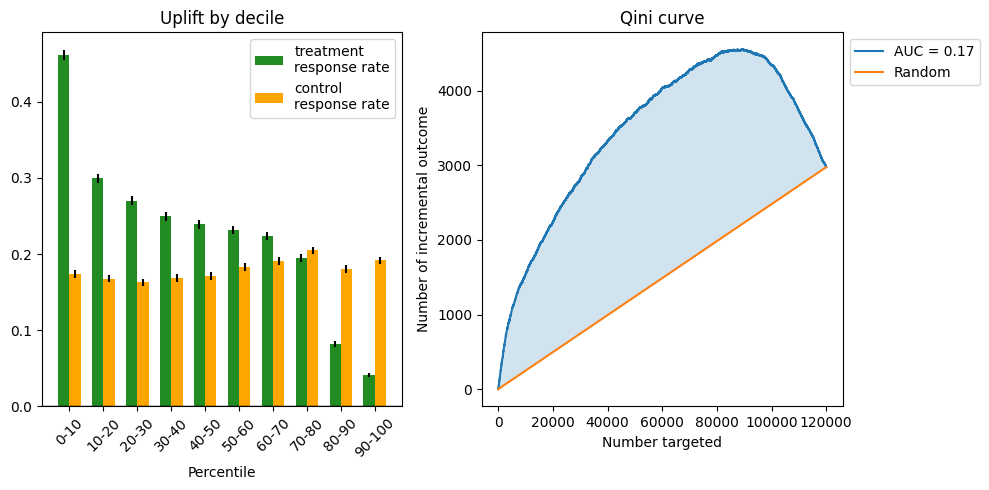

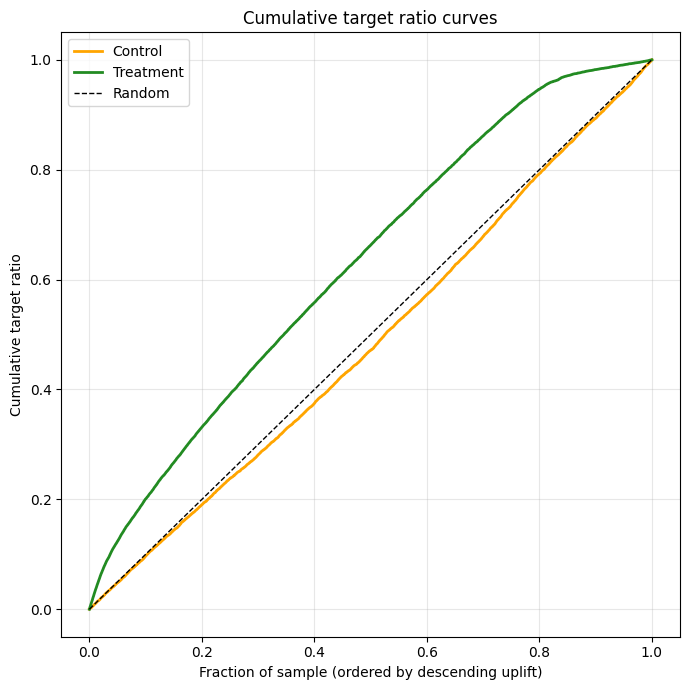

In [12]:
from auf.pipeline.evaluation import evaluate_model

evaluate_model(
    base_cols_mapper=base_cols_mapper,
    treatment_groups_mapper=treatment_groups_mapper,
    data=df2,
    preprocessor=preprocessor,
    model=model,
    evaluation_types = [
        'target_info',
        'metrics_table',
        'buckets_table',
        'tops_table',
        "buckets_qini_plots",
        "target_ratios_plots",
    ],
    # n_uplift_bins: int = 10,
)